# **ME630 -Assignment 1 - Problem Statement 8**

**Name:** Meghaj Nandumar Barhate  
**Programme:** M.Tech. in Fluid and Thermal Sciences  
**Roll Number:** 261050047 

---

> # Hollow cylinder with an insulated bore under one-sided flux

Consider a hollow cylinder (tube) of inner radius $R_i$ and outer radius $R_o$. One half of its outer circumference is exposed to a solar-type heat flux, while the entire outer circumference is cooled by convection. The inner bore is insulated.

### Governing Equation

For steady-state conduction with no internal heat generation,

$$
\frac{1}{r}\frac{\partial}{\partial r}
\left(
r\frac{\partial T}{\partial r}
\right)
+
\frac{1}{r^2}\frac{\partial^2 T}{\partial \theta^2}
=0,
\qquad
R_i \leq r \leq R_o,
\quad
0 \leq \theta < 2\pi.
$$

### Boundary Conditions

At the insulated inner surface,

$$
\left.
\frac{\partial T}{\partial r}
\right|_{r=R_i}
=0.
$$

At the outer surface,

$$
-k
\left.
\frac{\partial T}{\partial r}
\right|_{r=R_o}
=
h\left(T(R_o,\theta)-T_\infty\right)-q''(\theta).
$$

The applied circumferential heat flux is

$$
q''(\theta)=
\begin{cases}
q_0''\sin\theta, & 0<\theta<\pi,\\
0, & \pi<\theta<2\pi.
\end{cases}
$$

### Data

$$
R_i = 0.02\ \text{m},
\qquad
R_o = 0.05\ \text{m},
$$

$$
k = 20\ \text{W/(m K)},
\qquad
h = 15\ \text{W/(m}^2\text{ K)},
$$

$$
T_\infty = 25^\circ\text{C},
\qquad
q_0'' = 1200\ \text{W/m}^2.
$$

---

## Analytical Solution

Because the bore at $r=R_i$ is insulated, each harmonic must independently satisfy the zero-gradient condition at $R_i$. Define

$$
f_n(r)=r^n+R_i^{2n}r^{-n},
$$

which automatically satisfies

$$
f_n'(R_i)=0
$$

for every $n$.

Express the applied heat flux as a Fourier series,

$$
q''(\theta)
=
a_0+\sum_{n\geq 1}
\left(
a_n\cos n\theta+b_n\sin n\theta
\right).
$$

For the half-wave-rectified sine distribution,

$$
a_0=\frac{q_0''}{\pi},
\qquad
b_1=\frac{q_0''}{2},
$$

and

$$
a_{2m}
=
-\frac{2q_0''}{\pi(4m^2-1)},
\qquad
m=1,2,3,\ldots
$$

with all other Fourier coefficients equal to zero.

The resulting temperature distribution satisfying both radial boundary conditions is

$$
T(r,\theta)
=
T_\infty
+
\frac{a_0}{h}
+
\frac{b_1f_1(r)}
{hf_1(R_o)+kf_1'(R_o)}
\sin\theta
+
\sum_{m=1}^{\infty}
\frac{a_{2m}f_{2m}(r)}
{hf_{2m}(R_o)+kf_{2m}'(R_o)}
\cos(2m\theta).
$$

### Limiting Check

As $R_i\rightarrow 0$,

$$
f_n(r)\rightarrow r^n,
$$

$$
f_n(R_o)\rightarrow R_o^n,
$$

and

$$
f_n'(R_o)\rightarrow nR_o^{n-1}.
$$

Hence, the hollow-cylinder solution approaches the corresponding solid-cylinder result.

---

> ## Tasks

### (a) Boundary-Condition Matching

Derive the boundary-condition matching that produces $f_n(r)$ and the coefficient formula given above. Show the algebra that leads from the general radial solution involving $r^n$ and $r^{-n}$ to the stated result.

### (b) Finite-Difference Discretization

Discretize the annulus on a grid with

$$
\Delta r=\frac{R_o-R_i}{M},
\qquad
\Delta\theta=\frac{2\pi}{N},
$$

with periodicity in $\theta$.

No pole treatment is required because the origin is not part of the computational domain. Derive the discretized insulated-bore boundary condition at

$$
r=R_i,
$$

using either a ghost-node formulation or a one-sided finite-difference approximation.

### (c) Numerical Solution and Comparison

Solve the linear system

$$
[A]\{T\}=\{b\}
$$

using:

- a direct method,
- Gauss-Seidel iteration,
- SOR iteration.

Compare the numerical outer-surface temperature $T(R_o,\theta)$ with the analytical-series solution at

$$
\theta=0^\circ,\ 90^\circ,\ 180^\circ,\ 270^\circ.
$$

Also determine the locations and temperatures of the hottest and coldest points on the outer surface.

### (d) Energy-Conservation and Boundary-Condition Verification

Verify overall energy conservation by evaluating

$$
\oint_0^{2\pi}
\left[
q''(\theta)
-
h\left(T(R_o,\theta)-T_\infty\right)
\right]
R_o\,d\theta
\approx 0.
$$

Separately confirm that the radial heat flux at the insulated inner surface,

$$
r=R_i,
$$

is numerically zero everywhere. This serves as a verification of the insulated-bore boundary-condition implementation.

### (e) Limiting-Case Validation

Re-run the annulus solver with the inner radius reduced to

$$
R_i=0.001R_o,
$$

so that the geometry approaches a solid cylinder.

Using the same values of $R_o$, $k$, $h$, $T_\infty$, and $q_0''$, verify that the computed temperature field $T(r,\theta)$ converges to the corresponding solid-cylinder analytical solution.

Report the residual difference as

$$
R_i\rightarrow 0.
$$

---


### Library Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import os
import time as t
%pip install -qq numpy scipy matplotlib psutil ipympl
%matplotlib widget
%matplotlib widget
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Arc

Note: you may need to restart the kernel to use updated packages.


> ## **Problem Diagram**

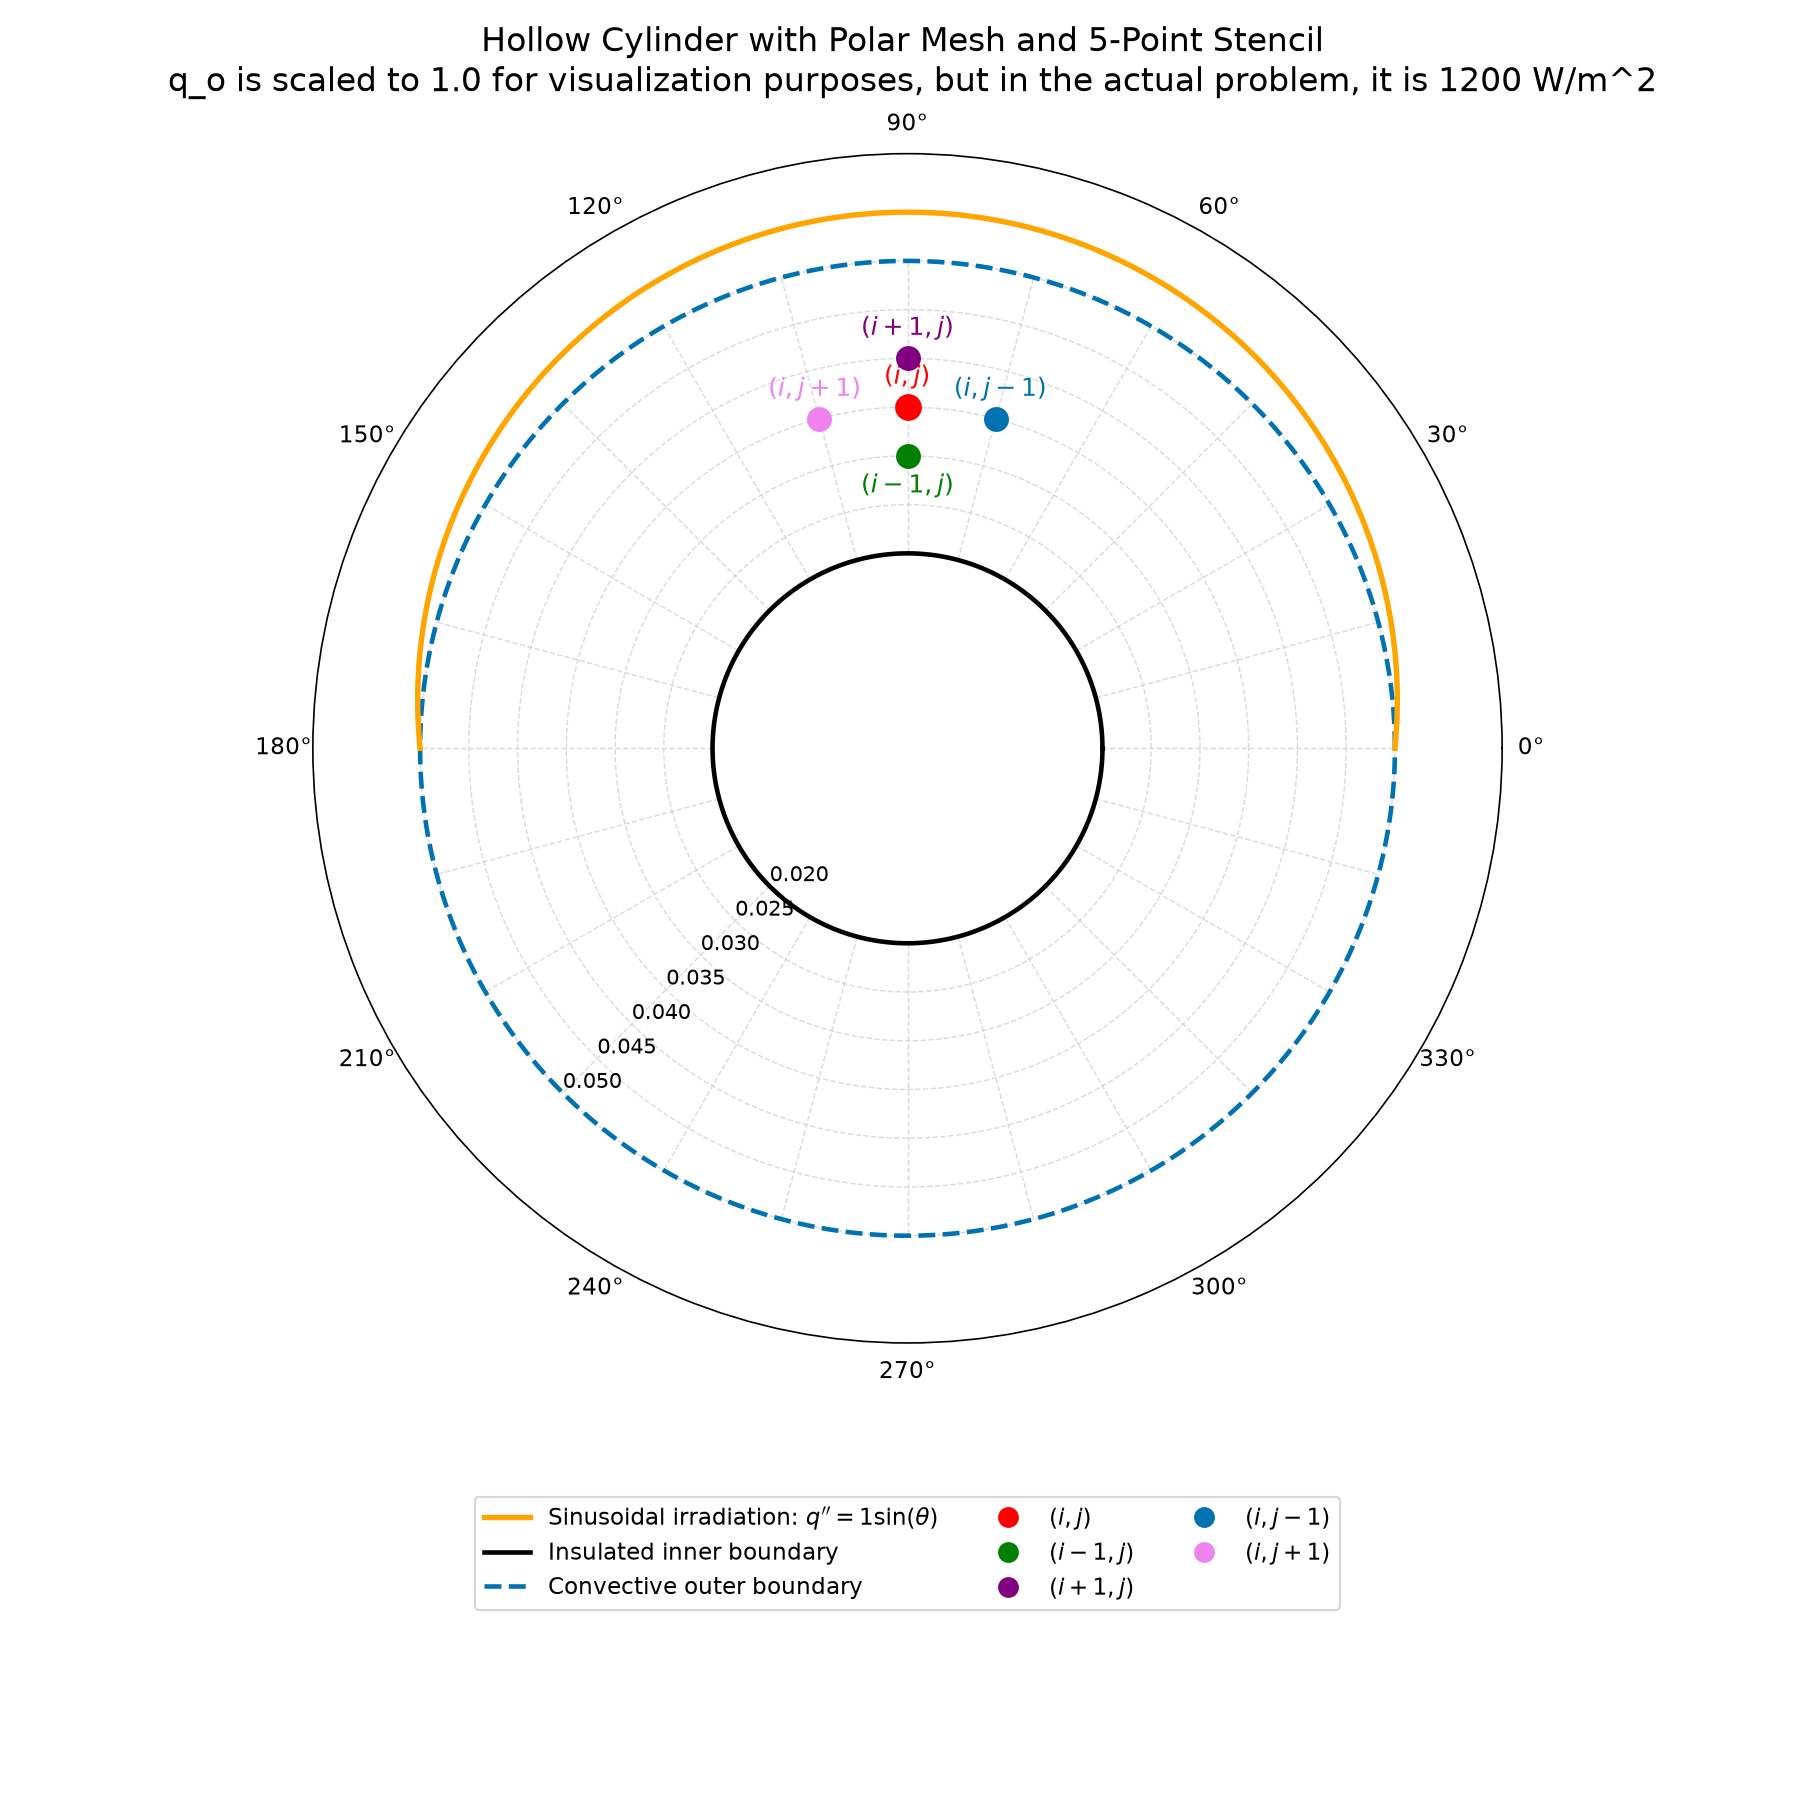

In [2]:
from matplotlib.lines import Line2D

def PlotProblemGeometry(innerRadius, outerRadius, deltaR):
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150, subplot_kw={'projection': 'polar'})
    latexBlue = '#0072B2'
    meshColor = 'lightgrey'
    theta = np.linspace(0, 2 * np.pi, 1000)

    # Polar mesh
    radiusValues = np.arange(innerRadius, outerRadius + 0.5 * deltaR, deltaR)
    for radius in radiusValues:
        ax.plot(theta, np.full_like(theta, radius), linestyle='--', color=meshColor, linewidth=0.7, alpha=0.8, zorder=0)
    deltaTheta = np.pi / 12
    thetaValues = np.arange(0, 2 * np.pi, deltaTheta)
    for angle in thetaValues:
        ax.plot([angle, angle], [innerRadius, outerRadius], linestyle='--', color=meshColor, linewidth=0.7, alpha=0.8, zorder=0)

    # Boundary conditions
    ax.plot(theta, np.full_like(theta, innerRadius), color='black', linewidth=2.2, zorder=2)
    ax.plot(theta, np.full_like(theta, outerRadius), color=latexBlue, linestyle='--', linewidth=2.2, zorder=2)
    radiationTheta = np.linspace(0, np.pi, 500)
    radiationProfile = 1.0 * np.sin(radiationTheta)
    radiationDisplayScale = deltaR
    radiationRadius = outerRadius + radiationDisplayScale * radiationProfile
    ax.plot(radiationTheta, radiationRadius, color='orange', linewidth=2.6, zorder=3)

    # Five-point dependency map
    pointRadius = innerRadius + 3 * deltaR
    pointTheta = np.pi / 2
    stencilPoints = {
        "(i,j)": (pointTheta, pointRadius),
        "(i,j-1)": (pointTheta - deltaTheta, pointRadius),
        "(i,j+1)": (pointTheta + deltaTheta, pointRadius),
        "(i-1,j)": (pointTheta, pointRadius - deltaR),
        "(i+1,j)": (pointTheta, pointRadius + deltaR)
    }

    ax.scatter(*stencilPoints["(i,j)"], s=140, color='red', zorder=5)
    ax.scatter(*stencilPoints["(i,j-1)"], s=120, color=latexBlue, zorder=5)
    ax.scatter(*stencilPoints["(i,j+1)"], s=120, color='violet', zorder=5)
    ax.scatter(*stencilPoints["(i-1,j)"], s=120, color='green', zorder=5)
    ax.scatter(*stencilPoints["(i+1,j)"], s=120, color='purple', zorder=5)

    textOffset = 0.0018
    ax.text(pointTheta, pointRadius + textOffset, r'$(i,j)$', color='red', fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta - deltaTheta, pointRadius + textOffset, r'$(i,j-1)$', color=latexBlue, fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta + deltaTheta, pointRadius + textOffset, r'$(i,j+1)$', color='violet', fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta, pointRadius - deltaR - textOffset, r'$(i-1,j)$', color='green', fontsize=12, ha='center', va='top')
    ax.text(pointTheta, pointRadius + deltaR + textOffset, r'$(i+1,j)$', color='purple', fontsize=12, ha='center', va='bottom')

    # Polar axes
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    angleTicks = np.arange(0, 360, 30)
    ax.set_thetagrids(angleTicks, fontsize=11)

    radialTicks = np.arange(innerRadius, outerRadius + 0.5 * deltaR, deltaR)
    ax.set_yticks(radialTicks)
    ax.set_yticklabels([f'{radius:.3f}' for radius in radialTicks], fontsize=10)
    ax.set_rlabel_position(225)
    ax.set_ylim(0, outerRadius + 2.2 * deltaR)
    ax.grid(False)

    legendHandles = [
        Line2D([0], [0], color='orange', linewidth=2.6, label=r'Sinusoidal irradiation: $q^{\prime\prime}=1\sin(\theta)$'),
        Line2D([0], [0], color='black', linewidth=2.2, label='Insulated inner boundary'),
        Line2D([0], [0], color=latexBlue, linestyle='--', linewidth=2.2, label='Convective outer boundary'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='red', markeredgecolor='red', markersize=9, label=r'$(i,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='green', markeredgecolor='green', markersize=9, label=r'$(i-1,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='purple', markeredgecolor='purple', markersize=9, label=r'$(i+1,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=latexBlue, markeredgecolor=latexBlue, markersize=9, label=r'$(i,j-1)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='violet', markeredgecolor='violet', markersize=9, label=r'$(i,j+1)$')
    ]

    ax.legend(handles=legendHandles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11, frameon=True)
    ax.set_title('Hollow Cylinder with Polar Mesh and 5-Point Stencil \n q_o is scaled to 1.0 for visualization purposes, but in the actual problem, it is 1200 W/m^2', fontsize=16, pad=30)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

innerRadius = 0.02
outerRadius = 0.05
deltaR = 0.005

PlotProblemGeometry(innerRadius, outerRadius, deltaR)

> ## **Problem Value Definitions**

In [3]:
innerRadius = 0.02
innerRadiusLimitting = 0.002
outerRadius = 0.05
thermalConductivity = 20
convectionCoefficient = 15
ambientTemperature = 25
heatFluxAmplitude = 1200

### Analytical Solution Plot

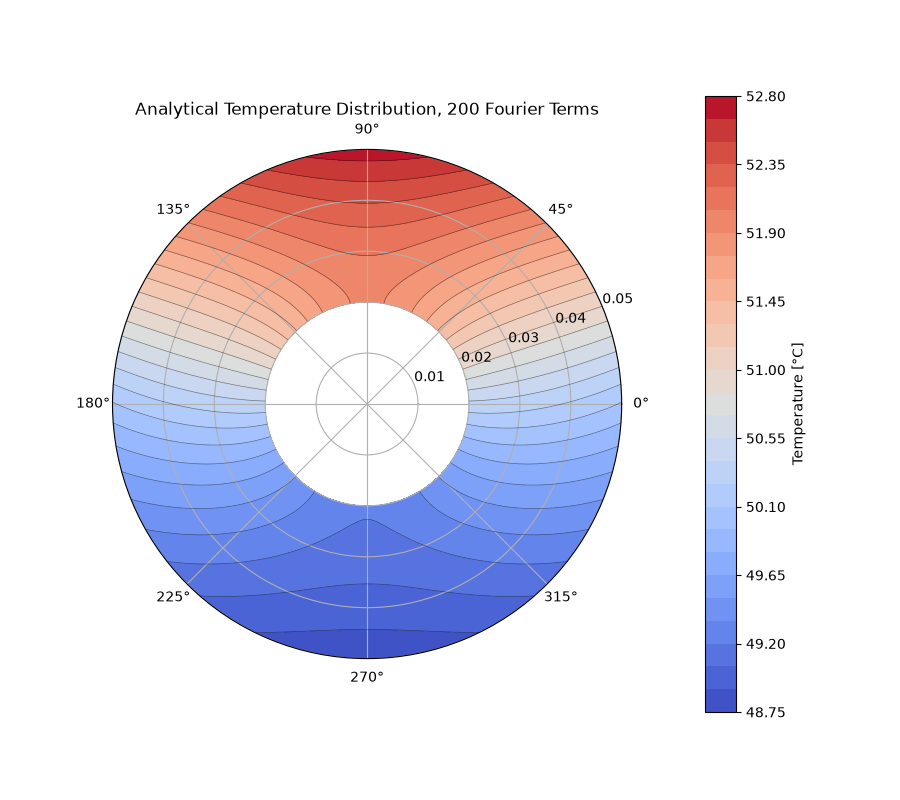

array([[50.36058365, 50.37245304, 50.38435495, ..., 50.33694604,
        50.34874768, 50.36058365],
       [50.36057342, 50.3724431 , 50.38434529, ..., 50.33693527,
        50.34873718, 50.36057342],
       [50.36054302, 50.37241352, 50.38431655, ..., 50.33690325,
        50.34870597, 50.36054302],
       ...,
       [50.09108623, 50.10837808, 50.12598292, ..., 50.05751247,
        50.07414155, 50.09108623],
       [50.08856577, 50.10590796, 50.12357565, ..., 50.05496903,
        50.07160335, 50.08856577],
       [50.0860129 , 50.10341293, 50.12114802, ..., 50.0524051 ,
        50.06904016, 50.0860129 ]], shape=(220, 721))

In [4]:
def RadialRatio(radius, eigenModeNumber, innerRadius, outerRadius, convectionCoefficient, thermalConductivity):
    radiusRatio = radius / outerRadius
    innerRadiusRatio = innerRadius / outerRadius
    innerRadiusPower = innerRadiusRatio ** (2 * eigenModeNumber)
    radialNumerator = radiusRatio ** eigenModeNumber + innerRadiusPower * radiusRatio ** (-eigenModeNumber)
    radialDenominator = convectionCoefficient * (1 + innerRadiusPower) + (thermalConductivity * eigenModeNumber / outerRadius) * (1 - innerRadiusPower)
    return radialNumerator / radialDenominator


def AnalyticalTemperature(radius, theta, innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms):
    temperature = np.full_like(radius, ambientTemperature + heatFluxAmplitude / (np.pi * convectionCoefficient), dtype=float)
    temperature += (heatFluxAmplitude / 2) * RadialRatio(radius, 1, innerRadius, outerRadius, convectionCoefficient, thermalConductivity) * np.sin(theta)
    for m in range(1, numberOfTerms + 1):
        eigenModeNumber = 2 * m
        eigenModeCoefficient = -2 * heatFluxAmplitude / (np.pi * (4 * m ** 2 - 1))
        temperature += eigenModeCoefficient * RadialRatio(radius, eigenModeNumber, innerRadius, outerRadius, convectionCoefficient, thermalConductivity) * np.cos(eigenModeNumber * theta)
    return temperature


def PlotAnalyticalTemperatureContour(innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms=50):
    radiusValues = np.linspace(innerRadius, outerRadius, 220)
    thetaValues = np.linspace(0, 2 * np.pi, 721)
    thetaMesh, radiusMesh = np.meshgrid(thetaValues, radiusValues)
    temperatureField = AnalyticalTemperature(radiusMesh, thetaMesh, innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms)
    fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={'projection': 'polar'})
    temperatureContour = ax.contourf(thetaMesh, radiusMesh, temperatureField, levels=30, cmap='coolwarm')
    ax.contour(thetaMesh, radiusMesh, temperatureField, levels=30, colors='black', linewidths=0.45, alpha=0.5)
    fig.colorbar(temperatureContour, ax=ax, pad=0.12, label='Temperature [°C]')
    ax.set_title(f'Analytical Temperature Distribution, {numberOfTerms} Fourier Terms')
    ax.set_ylim(0, outerRadius)
    ax.grid(True)
    plt.show()
    return temperatureField

PlotAnalyticalTemperatureContour(innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms=200)

> ## **Mesh generation And Finite Difference Discretization**

In [62]:
boundaryConditions = ['None', 'Neumann', 'ConvectionRobin', 'RadiationConvectionRobin']

class ColorMap:
    def __init__(self, boundaryConditions):
        self.boundaryConditions = boundaryConditions
        self.colorMap = {
            'Internal': 'lightgrey',
            'Neumann': 'red',
            'ConvectionRobin': 'green',
            'RadiationConvectionRobin': 'purple'
        }

    def getColor(self, boundaryType):
        return self.colorMap.get(boundaryType, 'lightgrey')

colorMap = ColorMap(boundaryConditions)

class PointMapper:
    def __init__(self, radialIndex, angularIndex, outerRadialIndex, innerRadialIndex, cwAngularIndex, ccwAngularIndex, unifiedIndex):
        self.unifiedIndex = unifiedIndex
        self.radialIndex = radialIndex
        self.angularIndex = angularIndex
        self.outerRadialIndex = outerRadialIndex
        self.innerRadialIndex = innerRadialIndex
        self.cwAngularIndex = cwAngularIndex
        self.ccwAngularIndex = ccwAngularIndex
        self.prevRadialUnifiedIndex = None
        self.nextRadialUnifiedIndex = None
        self.prevAzimuthalUnifiedIndex = None
        self.nextAzimuthalUnifiedIndex = None
        self.pointCoefficient = None
        self.nextRadialUnifiedCoefficient = None
        self.prevRadialUnifiedCoefficient = None
        self.nextAzimuthalUnifiedCoefficient = None
        self.prevAzimuthalUnifiedCoefficient = None
        self.isBoundary = False
        self.boundaryType = None
    
class ConcentricMesh:
    def __init__(self, innerRadius, outerRadius, radialSteps, angularSteps):
        self.innerRadius = innerRadius
        self.outerRadius = outerRadius
        self.radialSteps = radialSteps
        self.angularSteps = angularSteps
        self.deltaR = (outerRadius - innerRadius) / radialSteps
        self.deltaTheta = 2 * np.pi / angularSteps
        self.nRadii = np.linspace(innerRadius, outerRadius, radialSteps + 1)
        self.nAngles = np.linspace(0, 2 * np.pi, angularSteps, endpoint=False)
        self.numElements = (radialSteps + 1) * angularSteps
        self.pointMap = {}

def ComputePointMapping(mesh):
    prevRadialIndex = None
    nextRadialIndex = None
    prevAzimuthalIndex = None
    nextAzimuthalIndex = None
    currentUnifiedIndex = None
    nextRadialUnifiedIndex = None
    prevRadialUnifiedIndex = None
    nextAzimuthalUnifiedIndex = None
    prevAzimuthalUnifiedIndex = None
    currentBoundaryType = None
    currentBoundaryBool = False

    for radialIndex in range(0, mesh.radialSteps + 1):
        for azimuthalIndex in range(0, mesh.angularSteps):

            currentUnifiedIndex = azimuthalIndex + ((mesh.angularSteps) * radialIndex)
            # print(f"Current Unified Index: {currentUnifiedIndex}, Radial Index: {radialIndex}, Azimuthal Index: {azimuthalIndex}")

            if currentUnifiedIndex < mesh.angularSteps:
                prevRadialIndex = None
                nextRadialIndex = radialIndex + 1
                currentBoundaryType = 'Neumann'
                currentBoundaryBool = True
            elif (currentUnifiedIndex >= mesh.numElements - mesh.angularSteps):
                nextRadialIndex = None
                prevRadialIndex = radialIndex - 1
                currentBoundaryBool = True
                if azimuthalIndex > 0 and azimuthalIndex < (int(mesh.angularSteps/2)):
                    currentBoundaryType = 'RadiationConvectionRobin'
                else:
                    currentBoundaryType = 'ConvectionRobin'
            else:
                nextRadialIndex = radialIndex + 1
                prevRadialIndex = radialIndex - 1
                currentBoundaryType = 'None'
                currentBoundaryBool = False

            #****** if (azimuthalIndex % mesh.angularSteps == 11):
            if (azimuthalIndex % mesh.angularSteps == mesh.angularSteps - 1):
                nextAzimuthalIndex = 0
                prevAzimuthalIndex = azimuthalIndex - 1
            elif (azimuthalIndex % mesh.angularSteps == 0):
                nextAzimuthalIndex = azimuthalIndex + 1
                prevAzimuthalIndex = mesh.angularSteps - 1
            else:
                nextAzimuthalIndex = azimuthalIndex + 1
                prevAzimuthalIndex = azimuthalIndex - 1

            mesh.pointMap[currentUnifiedIndex] = PointMapper(radialIndex, azimuthalIndex, nextRadialIndex, prevRadialIndex, nextAzimuthalIndex, prevAzimuthalIndex, currentUnifiedIndex)

            #****** if(prevRadialIndex is not None) and (nextRadialIndex is not None):
            if(nextRadialIndex is not None):
                nextRadialUnifiedIndex = nextRadialIndex * mesh.angularSteps + azimuthalIndex
            else:
                nextRadialUnifiedIndex = None

            if(prevRadialIndex is not None):
                prevRadialUnifiedIndex = prevRadialIndex * mesh.angularSteps + azimuthalIndex
            else:
                prevRadialUnifiedIndex = None

            #******     nextAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + nextAzimuthalIndex
            nextAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + nextAzimuthalIndex
            #******     prevAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + prevAzimuthalIndex
            prevAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + prevAzimuthalIndex

            mesh.pointMap[currentUnifiedIndex].nextRadialUnifiedIndex = nextRadialUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].prevRadialUnifiedIndex = prevRadialUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].nextAzimuthalUnifiedIndex = nextAzimuthalUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].prevAzimuthalUnifiedIndex = prevAzimuthalUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].isBoundary = currentBoundaryBool
            mesh.pointMap[currentUnifiedIndex].boundaryType = currentBoundaryType
            #print all data in Line
            print(f"Unified Index: {currentUnifiedIndex}, Radial: {radialIndex}, Azimuthal: {azimuthalIndex}, Next Radial: {nextRadialIndex}, Prev Radial: {prevRadialIndex}, Next Azimuthal: {nextAzimuthalIndex}, Prev Azimuthal: {prevAzimuthalIndex}, Is Boundary: {currentBoundaryBool}, Boundary Type: {currentBoundaryType}")

mesh1 = ConcentricMesh(innerRadius, outerRadius, radialSteps = 3, angularSteps=12)
print(mesh1.numElements)
ComputePointMapping(mesh1)


48
Unified Index: 0, Radial: 0, Azimuthal: 0, Next Radial: 1, Prev Radial: None, Next Azimuthal: 1, Prev Azimuthal: 11, Is Boundary: True, Boundary Type: Neumann
Unified Index: 1, Radial: 0, Azimuthal: 1, Next Radial: 1, Prev Radial: None, Next Azimuthal: 2, Prev Azimuthal: 0, Is Boundary: True, Boundary Type: Neumann
Unified Index: 2, Radial: 0, Azimuthal: 2, Next Radial: 1, Prev Radial: None, Next Azimuthal: 3, Prev Azimuthal: 1, Is Boundary: True, Boundary Type: Neumann
Unified Index: 3, Radial: 0, Azimuthal: 3, Next Radial: 1, Prev Radial: None, Next Azimuthal: 4, Prev Azimuthal: 2, Is Boundary: True, Boundary Type: Neumann
Unified Index: 4, Radial: 0, Azimuthal: 4, Next Radial: 1, Prev Radial: None, Next Azimuthal: 5, Prev Azimuthal: 3, Is Boundary: True, Boundary Type: Neumann
Unified Index: 5, Radial: 0, Azimuthal: 5, Next Radial: 1, Prev Radial: None, Next Azimuthal: 6, Prev Azimuthal: 4, Is Boundary: True, Boundary Type: Neumann
Unified Index: 6, Radial: 0, Azimuthal: 6, Next 

> ## **Mesh Validation**

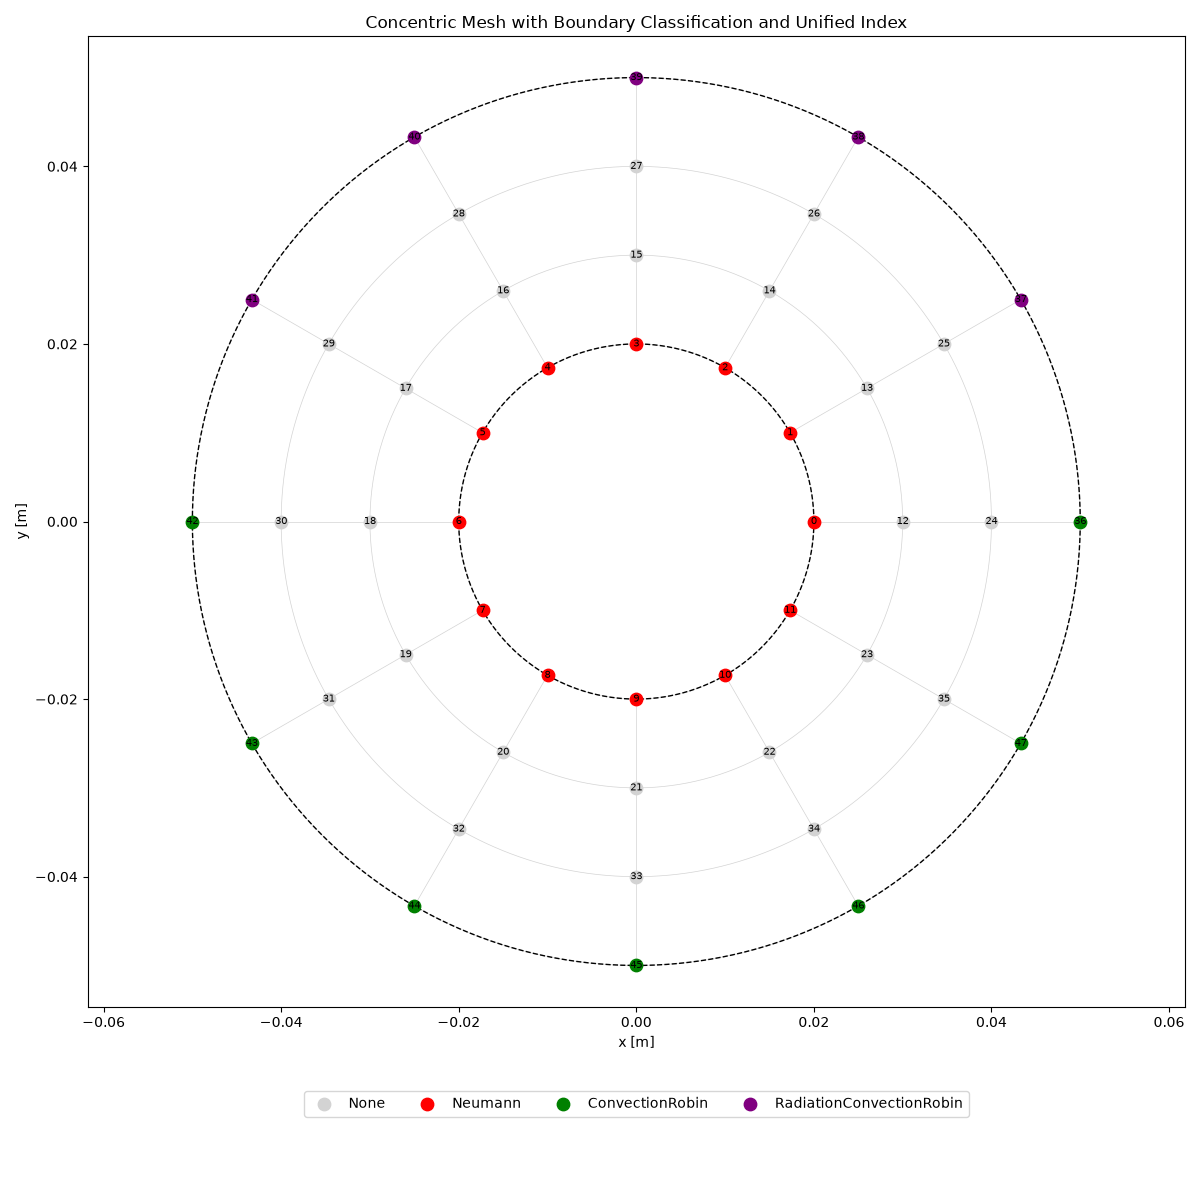

In [63]:
def PlotMeshValidation(mesh, colorMap):
    plt.figure(figsize=(12, 12))
    theta = np.linspace(0, 2 * np.pi, 1000)

    for radius in mesh.nRadii:
        plt.plot(radius * np.cos(theta), radius * np.sin(theta), color='lightgrey', linewidth=0.5, zorder=0)

    for angle in mesh.nAngles:
        plt.plot([mesh.innerRadius * np.cos(angle), mesh.outerRadius * np.cos(angle)], [mesh.innerRadius * np.sin(angle), mesh.outerRadius * np.sin(angle)], color='lightgrey', linewidth=0.5, zorder=0)

    plt.plot(mesh.innerRadius * np.cos(theta), mesh.innerRadius * np.sin(theta), 'k--', linewidth=1, zorder=1)
    plt.plot(mesh.outerRadius * np.cos(theta), mesh.outerRadius * np.sin(theta), 'k--', linewidth=1, zorder=1)

    for point in mesh.pointMap.values():
        radius = mesh.nRadii[point.radialIndex]
        angle = mesh.nAngles[point.angularIndex]
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        plt.scatter(x, y, color=colorMap.getColor(point.boundaryType), s=80, zorder=2)
        plt.text(x, y, str(point.unifiedIndex), fontsize=7, ha='center', va='center', zorder=3)

    for boundaryType in boundaryConditions:
        plt.scatter([], [], color=colorMap.getColor(boundaryType), s=80, label=boundaryType)

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Concentric Mesh with Boundary Classification and Unified Index")
    plt.axis("equal")
    plt.grid(False)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=10, frameon=True)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

PlotMeshValidation(mesh1, colorMap)

> ## **Defining Finite Difference Equations for Discretized Mesh**

## For Internal Node

Define:

$$
\alpha_i = \frac{\Delta r}{2r_i}
$$

$$
\beta_i = \frac{\Delta r^2}{r_i^2\Delta\theta^2}
$$

Then the finite difference approximation using central differences is:

$$
(1-\alpha_i)T_{prevRadPt}
+
(1+\alpha_i)T_{nxtRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2(1+\beta_i)T_{currentPt}
=
0
$$

---

## For Inner Neumann Boundary

For the insulated inner boundary:

$$
\frac{\partial T}{\partial r}=0
$$

Using the image point method:

$$
T_{prevRadPt}=T_{nxtRadPt}
$$

Then the finite difference equation becomes:

$$
2T_{nxtRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2(1+\beta_i)T_{currentPt}
=
0
$$

---

In [64]:
def Alpha(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    radius = mesh.nRadii[pointMapping.radialIndex]
    alphaValue = mesh.deltaR / (2 * radius)
    return alphaValue

def Beta(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    radius = mesh.nRadii[pointMapping.radialIndex]
    betaValue = (mesh.deltaR**2) / ((mesh.deltaTheta**2) * (radius**2))
    return betaValue

def InternalNodeFiniteDifference(mesh, unifiedPointIndex):
    if(not mesh.pointMap[unifiedPointIndex].isBoundary):       
        pointMapping = mesh.pointMap[unifiedPointIndex]
        equationCoeffs = np.zeros(mesh.numElements)
        betaValue = Beta(mesh, unifiedPointIndex)
        alphaValue = Alpha(mesh, unifiedPointIndex)
        print(f"Point Index: {pointMapping.unifiedIndex}, Radial Index: {pointMapping.radialIndex}, Angular Index: {pointMapping.angularIndex}, Beta: {betaValue:.6f}, Alpha: {alphaValue:.6f}")
        pointMapping.pointCoefficient = -2 * (1 + betaValue)
        pointMapping.nextRadialUnifiedCoefficient = (1 + alphaValue)
        pointMapping.prevRadialUnifiedCoefficient = (1 - alphaValue)
        pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
        pointMapping.prevAzimuthalUnifiedCoefficient = betaValue
        equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
        equationCoeffs[pointMapping.nextRadialUnifiedIndex] = pointMapping.nextRadialUnifiedCoefficient
        equationCoeffs[pointMapping.prevRadialUnifiedIndex] = pointMapping.prevRadialUnifiedCoefficient
        equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
        equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient
        rhsValue = 0
    return [equationCoeffs, rhsValue]

def InnerNeumannFiniteDifference(unifiedPointIndex):
    pointMapping = mesh1.pointMap[unifiedPointIndex]
    equationCoeffs = np.zeros(mesh1.numElements)
    betaValue = Beta(mesh1, unifiedPointIndex)

    pointMapping.pointCoefficient = -2 * (1 + betaValue)
    pointMapping.nextRadialUnifiedCoefficient = 2
    pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
    pointMapping.prevAzimuthalUnifiedCoefficient = betaValue

    equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
    equationCoeffs[pointMapping.nextRadialUnifiedIndex] = pointMapping.nextRadialUnifiedCoefficient
    equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
    equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient

    rhsValue = 0

    return [equationCoeffs, rhsValue]

print("Internal Node Finite Difference Coefficients:")
for unifiedPointIndex in range(mesh1.numElements):
    if not mesh1.pointMap[unifiedPointIndex].isBoundary:
        print(f"Unified Point Index: {unifiedPointIndex}, Coefficients: {InternalNodeFiniteDifference(mesh1, unifiedPointIndex)[0]}, RHS: {InternalNodeFiniteDifference(mesh1, unifiedPointIndex)[1]}")

print("Inner Neumann Boundary Finite Difference Coefficients:")
for unifiedPointIndex in range(mesh1.numElements):
    if mesh1.pointMap[unifiedPointIndex].boundaryType == 'Neumann':
        print(f"Unified Point Index: {unifiedPointIndex}, Coefficients: {InnerNeumannFiniteDifference(unifiedPointIndex)[0]}, RHS: {InnerNeumannFiniteDifference(unifiedPointIndex)[1]}")

Internal Node Finite Difference Coefficients:
Point Index: 12, Radial Index: 1, Angular Index: 0, Beta: 0.405285, Alpha: 0.166667
Point Index: 12, Radial Index: 1, Angular Index: 0, Beta: 0.405285, Alpha: 0.166667
Unified Point Index: 12, Coefficients: [ 0.83333333  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -2.81056947  0.40528473  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.40528473
  1.16666667  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.        ], RHS: 0
Point Index: 13, Radial Index: 1, Angular Index: 1, Beta: 0.405285, Alpha: 0.166667
Point Index: 13, Radial Index: 1, Angular Index: 1, Beta: 0.405285, Alpha: 0.166667
Unified Point Index: 13, Coefficie


## For Outer Convective Robin Boundary

Define:

$$
\alpha_i = \frac{\Delta r}{2r_i}
$$

$$
\beta_i = \frac{\Delta r^2}{r_i^2\Delta\theta^2}
$$

$$
\gamma = \frac{h\Delta r}{k}
$$

At the outer boundary:

$$
-k\frac{\partial T}{\partial r}
=
h(T-T_\infty)
$$

Using the image point method:

$$
T_{nxtRadPt}
=
T_{prevRadPt}
-
2\gamma(T_{currentPt}-T_\infty)
$$

Then the finite difference equation becomes:

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)\gamma T_\infty
$$

---

## For Combined Convective-Radiative Robin Boundary

The outer boundary condition is:
$$
-k\left.\frac{\partial T}{\partial r}\right|_{r=R_o}
=
h(T_{currentPt}-T_\infty)-q''(\theta)
$$

where the incident irradiation is:

$$
q''(\theta)=
\begin{cases}
q_0''\sin\theta, & 0<\theta<\pi,\\
0, & \pi<\theta<2\pi.
\end{cases}
$$

Using the image point method:

$$
-k\frac{T_{nxtRadPt}-T_{prevRadPt}}{2\Delta r}
=
h(T_{currentPt}-T_\infty)-q''(\theta)
$$

Therefore:

$$
T_{nxtRadPt}
=
T_{prevRadPt}
-
2\gamma(T_{currentPt}-T_\infty)
+
\frac{2\Delta r}{k}q''(\theta)
$$

Then the finite difference equation becomes:

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)
\left[
\gamma T_\infty
+
\frac{\Delta r}{k}q''(\theta)
\right]
$$

### For the irradiated half, $0<\theta<\pi$

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)
\left[
\gamma T_\infty
+
\frac{\Delta r}{k}q_0''\sin\theta
\right]
$$

### For the convective-only half, $\pi<\theta<2\pi$

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)\gamma T_\infty
$$

---

In [65]:
def Gamma(mesh):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    radius = mesh.nRadii[pointMapping.radialIndex]
    gammaValue = (convectionCoefficient * mesh.deltaR) / (thermalConductivity)
    return gammaValue

def OuterConvectionRobinFiniteDifference(unifiedPointIndex):
    pointMapping = mesh1.pointMap[unifiedPointIndex]
    equationCoeffs = np.zeros(mesh1.numElements)
    betaValue = Beta(mesh1, unifiedPointIndex)
    alphaValue = Alpha(mesh1, unifiedPointIndex)
    gammaValue = (convectionCoefficient * mesh1.deltaR) / thermalConductivity
    pointMapping.pointCoefficient = -2 * ((1 + betaValue) + (1 + alphaValue) * gammaValue)
    pointMapping.prevRadialUnifiedCoefficient = 2
    pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
    pointMapping.prevAzimuthalUnifiedCoefficient = betaValue
    equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
    equationCoeffs[pointMapping.prevRadialUnifiedIndex] = pointMapping.prevRadialUnifiedCoefficient
    equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
    equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient
    rhsValue = -2 * (1 + alphaValue) * gammaValue * ambientTemperature
    return [equationCoeffs, rhsValue]

def RadiationConvectionRobinFiniteDifference(unifiedPointIndex):
    pointMapping = mesh1.pointMap[unifiedPointIndex]
    equationCoeffs = np.zeros(mesh1.numElements)
    betaValue = Beta(mesh1, unifiedPointIndex)
    alphaValue = Alpha(mesh1, unifiedPointIndex)
    gammaValue = (convectionCoefficient * mesh1.deltaR) / thermalConductivity
    theta = mesh1.nAngles[pointMapping.angularIndex]

    if theta > 0 and theta < np.pi:
        incidentHeatFlux = heatFluxAmplitude * np.sin(theta)
    else:
        incidentHeatFlux = 0

    pointMapping.pointCoefficient = -2 * ((1 + betaValue) + (1 + alphaValue) * gammaValue)
    pointMapping.prevRadialUnifiedCoefficient = 2
    pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
    pointMapping.prevAzimuthalUnifiedCoefficient = betaValue

    equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
    equationCoeffs[pointMapping.prevRadialUnifiedIndex] = pointMapping.prevRadialUnifiedCoefficient
    equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
    equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient

    rhsValue = -2 * (1 + alphaValue) * (gammaValue * ambientTemperature + (mesh1.deltaR / thermalConductivity) * incidentHeatFlux)

    return [equationCoeffs, rhsValue]


print("Outer Convection Robin Finite Difference Coefficients:")
for unifiedPointIndex in range(mesh1.numElements):
    if mesh1.pointMap[unifiedPointIndex].isBoundary and mesh1.pointMap[unifiedPointIndex].boundaryType == 'ConvectionRobin':
        print(f"Unified Point Index: {unifiedPointIndex}, Coefficients: {OuterConvectionRobinFiniteDifference(unifiedPointIndex)[0]}, RHS: {OuterConvectionRobinFiniteDifference(unifiedPointIndex)[1]}")

print("Radiation Convection Robin Finite Difference Coefficients:")
for unifiedPointIndex in range(mesh1.numElements):
    if mesh1.pointMap[unifiedPointIndex].isBoundary and mesh1.pointMap[unifiedPointIndex].boundaryType == 'RadiationConvectionRobin':
        print(f"Unified Point Index: {unifiedPointIndex}, Coefficients: {RadiationConvectionRobinFiniteDifference(unifiedPointIndex)[0]}, RHS: {RadiationConvectionRobinFiniteDifference(unifiedPointIndex)[1]}")

Outer Convection Robin Finite Difference Coefficients:
Unified Point Index: 36, Coefficients: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  2.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -2.30830501  0.1459025   0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.1459025 ], RHS: -0.41250000000000003
Unified Point Index: 42, Coefficients: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0

> ## **Matrix Setup**